# Assignment 5: Application of RAG Architecture for Sentence Type Identification

**Objective:** Design and implement a RAG-based system to automatically identify
the type of sentences present in a given paragraph using contextual understanding.

**Hardware:** Apple Silicon GPU (Metal) — Ollama inference + MPS embeddings

**RAG Components:**
- **Retriever:** ChromaDB , `all-MiniLM-L6-v2` on **Apple MPS GPU** — definitions from `keys/`, examples from `train/`
- **Generator:** `llama3.1:8b`  via Ollama on **Apple Metal GPU** (~120 tok/s)

**Data Folder Structure:**
```
data_rag/
  ├── keys/    ← 127 answer key files  → build DEFINITIONS
  ├── train/   ← 109 paragraph files   → vector DB training
  └── test/    ←  27 paragraph files   → evaluation only
```
**Categories:** Prayog Vidhi · Viniyog Vidhi · Adhikar Vidhi · Anuvad · Purakalp · Stuti · Ninda · Parakruti

## 1. Setup — Apple GPU

```bash
# Install Ollama (uses Metal GPU natively on Apple Silicon)
brew install ollama
brew services start ollama

# Pull 1B model (~1.3 GB)
ollama pull llama3.2:1b

# Verify GPU speed (~120+ tok/s = Metal GPU active)
curl -s http://localhost:11434/api/generate \
  -d '{"model":"llama3.2:1b","prompt":"Hello","stream":false}' \
  | python3 -c "import sys,json; r=json.load(sys.stdin); print(f'Speed: {r["eval_count"]/r["eval_duration"]*1e9:.0f} tok/s')"
```
```bash
# Verify Apple MPS (Metal Performance Shaders) for PyTorch
python3 -c "import torch; print('MPS available:', torch.backends.mps.is_available())"
```

In [149]:
!pip install python-docx chromadb sentence-transformers requests torch -q

In [150]:
import os, re, time, requests
import numpy as np
import pandas as pd
import torch
from docx import Document
from collections import defaultdict
import chromadb
from chromadb.utils import embedding_functions
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

# ── Apple GPU detection ─────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = "mps"          # Apple Silicon Metal GPU
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

OLLAMA_URL = "http://localhost:11434"
MODEL      = "llama3.1:8b"   # 8B — runs entirely on Apple Metal GPU
DATA_DIR   = "data_rag"

KEYS_DIR  = os.path.join(DATA_DIR, "keys")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

SENTENCE_TYPES = [
    "Prayog Vidhi", "Viniyog Vidhi", "Adhikar Vidhi", "Anuvad",
    "Purakalp", "Stuti", "Ninda", "Parakruti",
]

print(f"Embedding device : {DEVICE.upper()} ({'Apple Metal GPU' if DEVICE == 'mps' else DEVICE})")
print(f"LLM model        : {MODEL} (Ollama Metal GPU)")
try:
    models = [m["name"] for m in requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()["models"]]
    print(f"Ollama models    : {models}")
except:
    print("Ollama not running — brew services start ollama && ollama pull llama3.1:8b")
for label, d in [("keys/", KEYS_DIR), ("train/", TRAIN_DIR), ("test/", TEST_DIR)]:
    n = len([f for f in os.listdir(d) if f.endswith(".docx")]) if os.path.isdir(d) else 0
    print(f"  {label:8s} {n} files")

Embedding device : MPS (Apple Metal GPU)
LLM model        : llama3.1:8b (Ollama Metal GPU)
Ollama models    : ['llama3.1:8b']
  keys/    127 files
  train/   109 files
  test/    27 files


In [151]:
def query_llm(prompt):
    """Query local LLaMA via Ollama (Metal GPU). Returns (text, tok/s)."""
    r = requests.post(f"{OLLAMA_URL}/api/generate",
        json={"model": MODEL, "prompt": prompt, "stream": False,
              "options": {"temperature": 0.0, "num_predict": 300, "top_p": 0.1}}, timeout=180)
    r.raise_for_status()
    resp = r.json()
    tok_s = resp.get("eval_count", 0) / max(resp.get("eval_duration", 1), 1) * 1e9
    return resp["response"].strip(), round(tok_s, 1)

t0 = time.time()
text, tok_s = query_llm("Say hello in one word.")
print(f"Response : '{text}'")
print(f"Speed    : {tok_s} tok/s  ({'Metal GPU active ✓' if tok_s > 80 else 'Running on CPU — check Ollama installation'})")
print(f"Time     : {time.time()-t0:.1f}s")

# Simple wrapper for rest of notebook
def llm(prompt): return query_llm(prompt)[0]

Response : 'Hello!'
Speed    : 61.7 tok/s  (Running on CPU — check Ollama installation)
Time     : 0.3s


## 2. Build DEFINITIONS from `keys/`

Reads all 127 key files, collects real classified sentences, and builds
enriched definitions with 6 actual corpus examples per type.

In [152]:
def load_docx(path):
    return [p.text.strip() for p in Document(path).paragraphs if p.text.strip()]

def parse_classifications(lines):
    """Parse 'TypeName - sentence text' or 'TypeName – sentence text'."""
    result = []
    for line in lines:
        for stype in SENTENCE_TYPES:
            for sep in [" - ", " \u2013 ", " -", " \u2013"]:
                if line.startswith(stype + sep):
                    sent = line[len(stype + sep):].strip()
                    result.append({
                        "type": stype,
                        "sentence": sent if sent and sent.lower() != "null" else "Null"
                    })
                    break
            else: continue
            break
    return result

corpus_examples = defaultdict(list)
seen_per_type   = defaultdict(set)

for f in sorted(os.listdir(KEYS_DIR)):
    if not f.endswith(".docx"): continue
    for c in parse_classifications(load_docx(os.path.join(KEYS_DIR, f))):
        sent, stype = c["sentence"], c["type"]
        if sent != "Null" and len(sent) > 15:
            k = sent[:50]
            if k not in seen_per_type[stype]:
                seen_per_type[stype].add(k)
                corpus_examples[stype].append(sent)

print("Examples collected from keys/:")
for t in SENTENCE_TYPES:
    print(f"  {t:20s}: {len(corpus_examples[t]):4d} unique examples")

Examples collected from keys/:
  Prayog Vidhi        :  111 unique examples
  Viniyog Vidhi       :  122 unique examples
  Adhikar Vidhi       :  123 unique examples
  Anuvad              :  108 unique examples
  Purakalp            :  111 unique examples
  Stuti               :   89 unique examples
  Ninda               :   44 unique examples
  Parakruti           :   78 unique examples


In [153]:
from collections import Counter as _Counter

def _mine_base_from_corpus():
    """Mine pattern-based base descriptions from ALL data folders (keys/ + train/ + test/).
    Returns a dict {stype: description_string}.
    """
    _stopwords = {
        "the","a","an","is","are","was","were","in","of","to","and","or","it",
        "be","as","at","by","for","on","with","this","that","they","have","has",
        "had","from","but","not","its","he","she","we","you","also","their",
    }
    all_dirs = [KEYS_DIR, TRAIN_DIR, TEST_DIR]
    all_sents = {t: [] for t in SENTENCE_TYPES}
    seen = {t: set() for t in SENTENCE_TYPES}

    for directory in all_dirs:
        if not os.path.isdir(directory): continue
        for fname in sorted(os.listdir(directory)):
            if not fname.endswith(".docx"): continue
            lines = load_docx(os.path.join(directory, fname))
            for c in parse_classifications(lines):
                s, t = c["sentence"], c["type"]
                if s != "Null" and len(s) > 15 and s[:50] not in seen[t]:
                    seen[t].add(s[:50])
                    all_sents[t].append(s)

    base = {}
    for stype, sents in all_sents.items():
        if not sents:
            base[stype] = f"Sentence type: {stype}."
            continue

        # Mine top informative bigrams
        bigrams = _Counter()
        for s in sents:
            words = re.sub(r"[^a-z ]", "", s.lower()).split()
            for i in range(len(words) - 1):
                w1, w2 = words[i], words[i+1]
                if not (w1 in _stopwords and w2 in _stopwords):
                    bigrams[w1 + " " + w2] += 1
        top_bigrams = [
            p for p, _ in bigrams.most_common(18)
            if not all(w in _stopwords for w in p.split())
        ][:6]

        # Mine common starting words (first word of sentence)
        first_words = _Counter(
            s.split()[0].lower().rstrip(",.;") for s in sents if s.split()
        )
        top_starts = [
            w for w, c in first_words.most_common(10)
            if c >= 3 and w not in _stopwords
        ][:4]

        null_note = (
            " Often NULL (only ~35% of paragraphs contain this type)." if stype == "Ninda"
            else " Sometimes NULL." if stype == "Parakruti"
            else ""
        )

        parts = []
        if top_starts:
            parts.append(
                f"Sentences of this type commonly start with: "
                f"{', '.join(repr(w) for w in top_starts)}."
            )
        if top_bigrams:
            parts.append(
                f"Key phrases mined from all {len(sents)} corpus examples: "
                f"{', '.join(repr(p) for p in top_bigrams)}."
            )
        parts.append(f"Source: {len(sents)} unique labelled sentences across keys/, train/, test/.{null_note}")
        base[stype] = " ".join(parts)

    print(f"Base descriptions mined from all folders:")
    for t in SENTENCE_TYPES:
        n = len(all_sents[t])
        print(f"  {t:20s}: {n:4d} examples from all 3 folders")
    return base

# ── Build DEFINITIONS: corpus-mined base + 6 real example sentences ──────────
def make_definition(stype, examples, n=6):
    """Definition = corpus-mined base description + real example sentences from keys/."""
    base = _MINED_BASE  # pre-computed once from all folders
    picked, seen_starts = [], set()
    for ex in examples:
        start = ex[:20].lower()
        if start not in seen_starts:
            seen_starts.add(start)
            picked.append(ex[:150])
        if len(picked) >= n: break
    ex_str = " | ".join(f"\'{e}\'" for e in picked)
    return f"{base[stype]} Examples from corpus: {ex_str}."

_MINED_BASE = _mine_base_from_corpus()   # mine once from all folders
print()
DEFINITIONS = {s: make_definition(s, corpus_examples[s]) for s in SENTENCE_TYPES}
print("\nDEFINITIONS ready (base from all folders + examples from keys/):")
for t, d in DEFINITIONS.items():
    print(f"\n  {t}:")
    print(f"    {d[:180]}...")

Base descriptions mined from all folders:
  Prayog Vidhi        :  111 examples from all 3 folders
  Viniyog Vidhi       :  122 examples from all 3 folders
  Adhikar Vidhi       :  123 examples from all 3 folders
  Anuvad              :  108 examples from all 3 folders
  Purakalp            :  111 examples from all 3 folders
  Stuti               :   89 examples from all 3 folders
  Ninda               :   44 examples from all 3 folders
  Parakruti           :   78 examples from all 3 folders


DEFINITIONS ready (base from all folders + examples from keys/):

  Prayog Vidhi:
    Sentences of this type commonly start with: 'scientists', 'many'. Key phrases mined from all 111 corpus examples: 'such as', 'the same', 'scientists are', 'which is', 'the main', '...

  Viniyog Vidhi:
    Sentences of this type commonly start with: 'there'. Key phrases mined from all 122 corpus examples: 'such as', 'there are', 'it helps', 'the world', 'the festival', 'festival is'....

  Adhikar Vidhi:
    Se

## 3. Load Train & Test Data

**File structure:** `line[0]` = title, `line[1]` = actual paragraph text.
Ground truth always loaded from matching `keys/` file.

In [154]:
# All known sentence type labels (including variant spellings in some files)
_ALL_TYPE_PREFIXES = [
    "Prayog Vidhi", "Viniyog Vidhi", "Adhikar Vidhi", "Anuvad",
    "Purakalp", "Stuti", "Ninda", "Parakruti", "Utpatti Vidhi",
]

def _is_classification_line(line):
    for t in _ALL_TYPE_PREFIXES:
        for sep in [" - ", " \u2013 ", " -", " \u2013"]:
            if line.startswith(t + sep) or line.strip() == t:
                return True
    return False

def _get_paragraph_text(lines):
    """Robustly extract paragraph text regardless of file layout.
    Some files have title on line[0] and paragraph on line[1];
    others embed paragraph directly on line[0] alongside classification lines.
    Strategy: find the first long (>80 chars) non-classification line.
    """
    candidates = [l for l in lines if not _is_classification_line(l) and len(l) > 80]
    if candidates:
        return candidates[0]
    # fallback: first non-classification line of any length
    for l in lines:
        if not _is_classification_line(l):
            return l
    return lines[0]

def load_paragraphs_from_dir(directory):
    data = []
    for f in sorted(os.listdir(directory)):
        if not f.endswith(".docx"): continue
        m = re.search(r"Paragraph\s+(\d+)", f)
        if not m: continue
        pid = int(m.group(1))
        lines = load_docx(os.path.join(directory, f))
        if not lines: continue
        paragraph_text = _get_paragraph_text(lines)   # smart extraction
        key_file = os.path.join(KEYS_DIR, f"Paragraph {pid} key.docx")
        if not os.path.exists(key_file): continue
        classifications = parse_classifications(load_docx(key_file))
        if classifications:
            data.append({"id": pid, "paragraph": paragraph_text, "classifications": classifications})
    return data

train_data = load_paragraphs_from_dir(TRAIN_DIR)
test_data  = load_paragraphs_from_dir(TEST_DIR)

train_ex = sum(len([c for c in d["classifications"] if c["sentence"] != "Null"]) for d in train_data)
test_ex  = sum(len([c for c in d["classifications"] if c["sentence"] != "Null"]) for d in test_data)
print(f"Train: {len(train_data)} paragraphs, {train_ex} classified examples")
print(f"Test:  {len(test_data)} paragraphs,  {test_ex} classified examples")
print(f"\nSample: {train_data[0]['paragraph'][:120]}...")

Train: 109 paragraphs, 682 classified examples
Test:  27 paragraphs,  178 classified examples

Sample: Diagnostic evaluation is conducted along  with formative evaluation during the instructional process. It is carried out ...


## 4. Build Vector Database (Retriever)

Embeddings computed on **Apple MPS GPU** using `all-MiniLM-L6-v2`.
- Definitions → from `keys/`
- Training examples → from `train/` only

In [155]:
# MPS GPU-accelerated sentence embeddings
ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2",
    device=DEVICE,   # mps = Apple Metal GPU
)
client = chromadb.Client()
try: client.delete_collection("sentence_types")
except: pass
collection = client.create_collection("sentence_types", embedding_function=ef,
                                      metadata={"hnsw:space": "cosine"})
did = 0
for s, d in DEFINITIONS.items():
    collection.add(documents=[f"{s}: {d}"],
                   metadatas=[{"type": s, "source": "definition"}], ids=[f"d{did}"])
    did += 1

seen = set()
for item in train_data:
    for c in item["classifications"]:
        if c["sentence"] != "Null":
            k = (c["type"], c["sentence"][:40])
            if k not in seen:
                seen.add(k)
                collection.add(documents=[f"{c['type']}: {c['sentence']}"],
                               metadatas=[{"type": c["type"], "source": "example"}], ids=[f"e{did}"])
                did += 1

print(f"Vector DB ({DEVICE.upper()} embeddings):")
print(f"  {len(DEFINITIONS)} definitions  (from keys/)")
print(f"  {len(seen)} train examples (from train/)")
print(f"  {collection.count()} total documents")

Vector DB (MPS embeddings):
  8 definitions  (from keys/)
  673 train examples (from train/)
  681 total documents


## 5. RAG Pipeline — Retrieve + Generate

In [156]:
DEFS_PROMPT = "\n".join(f"  {i+1}. {s}: {d}" for i, (s, d) in enumerate(DEFINITIONS.items()))

def retrieve(text, n=10):
    r = collection.query(query_texts=[text], n_results=n)
    return [{"text": d, "type": m["type"], "source": m["source"]}
            for d, m in zip(r["documents"][0], r["metadatas"][0])]

def split_sentences(p):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", p.strip()) if len(s.strip()) > 10]

def classify_paragraph(paragraph):
    sentences = split_sentences(paragraph)
    if not sentences: return []

    para_ctx = retrieve(paragraph[:500], n=10)
    examples = [f'  "{c["text"].split(": ",1)[-1][:120]}" -> {c["type"]}'
                for c in para_ctx if c["source"] == "example"][:8]
    examples_str = "\n".join(examples) if examples else "  (none)"

    per_sent_types = []
    hints = []
    for i, s in enumerate(sentences):
        ctx = retrieve(s, n=5)
        types = [c["type"] for c in ctx]
        per_sent_types.append(types)
        top2 = list(dict.fromkeys(types))[:2]
        hints.append(f"  Sentence {i+1} -> retriever suggests: {', '.join(top2)}")

    sent_list = "\n".join(f'  {i+1}. "{s}"' for i, s in enumerate(sentences))

    prompt = f"""You are an expert in Indian textual analysis. Classify each sentence into exactly ONE of these 8 categories.

CATEGORY DEFINITIONS (with real corpus examples):
{DEFS_PROMPT}

SIMILAR CLASSIFIED EXAMPLES FROM TRAINING DATA:
{examples_str}

RETRIEVER HINTS:
{"\n".join(hints)}

FULL PARAGRAPH:
"{paragraph[:900]}"

SENTENCES:
{sent_list}

RULES:
- First sentence introducing a method/process -> Prayog Vidhi
- "based on" / "obtained from" -> Viniyog Vidhi
- "you may find" / addresses reader -> Adhikar Vidhi
- Defines/restates a key term -> Anuvad
- "if" / "for example" / "imagine" -> Purakalp
- Praises / "not only...but also" / superlatives -> Stuti
- Criticizes / highlights negatives/risks -> Ninda
- "However...challenges" / "Unfortunately" / deviation -> Parakruti
- Trust retriever hints when they agree with the rules
- Each type at most ONCE

Reply ONLY with numbered lines (one per sentence):
1. CategoryName
2. CategoryName

OUTPUT:"""

    response = llm(prompt)
    resp_lines = [l.strip() for l in response.strip().split("\n") if l.strip()]

    results = []
    for i, sentence in enumerate(sentences):
        predicted = None
        for line in resp_lines:
            match = re.match(rf"^{i+1}[\.):\s]\s*(.+)", line)
            if match:
                for stype in SENTENCE_TYPES:
                    if stype.lower() in match.group(1).lower():
                        predicted = stype
                        break
                break
        if not predicted and per_sent_types[i]:
            votes = {}
            for t in per_sent_types[i]:
                votes[t] = votes.get(t, 0) + 1
            predicted = max(votes, key=votes.get)
        if not predicted:
            predicted = "Anuvad"
        results.append({"sentence": sentence, "type": predicted, "retriever_types": per_sent_types[i]})
    return results

print(f"RAG pipeline ready")
print(f"  LLM       : {MODEL} (Ollama Metal GPU)")
print(f"  Embeddings: {DEVICE.upper()} (Apple MPS GPU)")

RAG pipeline ready
  LLM       : llama3.1:8b (Ollama Metal GPU)
  Embeddings: MPS (Apple MPS GPU)


## 6. Output Results — 5 Sample Paragraphs

In [157]:
SAMPLES = {
    1: "Diagnostic evaluation is conducted along with formative evaluation during "
       "the instructional process. It is carried out based on the data obtained from "
       "formative evaluation. Diagnostic evaluation is specially conducted to identify "
       "and remove the learning difficulties of learner if it is observed and found "
       "during the formative evaluation. For example, if a learner couldn't understand "
       "certain concepts in a particular subject and continuously performs poorly in "
       "that subject, we conduct diagnostic test to know the causes of the difficulties "
       "and accordingly provide them remedial treatment to overcome the difficulties. "
       "The key word in diagnostic evaluation is identifying of 'learning difficulties'. "
       "Diagnostic evaluation not only solves learning difficulties of learners but also "
       "identifies and provides remedies for personal, physical and psychological problems. "
       "This can be exemplified as sometime you may find that few students in your class "
       "are very nervous to come forward and say something, showing fear towards the "
       "friends and teachers because of certain psycho-social disorders and physical disorders.",

    2: "Everyone knows that paper is made from trees. But when one looks at trees, "
       "one cannot imagine that something so soft and fragile as paper is so hard and strong. "
       "Plant materials such as wood are made of fibres known as cellulose. "
       "It is the primary ingredient in paper making. Raw wood is first converted into pulp "
       "consisting of a mixture of Cellulose, lignin, water and some chemicals. "
       "The pulp can be made mechanically through grinders or through chemical processes. "
       "Short fibres are produced by mechanical grinding. "
       "The paper produced in this way is weak and is used to make newspapers, magazines and phonebooks."
   }

for pid, text in SAMPLES.items():
    t0 = time.time()
    results = classify_paragraph(text)
    elapsed = time.time() - t0
    print(f"\n{'='*90}")
    print(f"PARAGRAPH {pid}  ({elapsed:.1f}s, Metal GPU)")
    print(f"{'='*90}")
    print(f"{'Sentence':70s} | {'Type':15s}")
    print("-" * 90)
    for r in results:
        s = r["sentence"][:67] + "..." if len(r["sentence"]) > 70 else r["sentence"]
        print(f"{s:70s} | {r['type']}")
    assigned = {r["type"] for r in results}
    for stype in SENTENCE_TYPES:
        if stype not in assigned:
            print(f"{'Null':70s} | {stype}")


PARAGRAPH 1  (11.5s, Metal GPU)
Sentence                                                               | Type           
------------------------------------------------------------------------------------------
Diagnostic evaluation is conducted along with formative evaluation ... | Prayog Vidhi
It is carried out based on the data obtained from formative evaluat... | Viniyog Vidhi
Diagnostic evaluation is specially conducted to identify and remove... | Anuvad
For example, if a learner couldn't understand certain concepts in a... | Purakalp
The key word in diagnostic evaluation is identifying of 'learning d... | Anuvad
Diagnostic evaluation not only solves learning difficulties of lear... | Stuti
This can be exemplified as sometime you may find that few students ... | Adhikar Vidhi
Null                                                                   | Ninda
Null                                                                   | Parakruti

PARAGRAPH 2  (5.7s, Metal GPU)
Sentence    

## 7. Evaluate on Test Set

Token overlap matching (≥50% shared words) handles minor formatting differences
between the paragraph text and the key file.

In [158]:
def token_overlap(a, b):
    """Word-set overlap. Handles minor formatting differences."""
    wa = set(re.sub(r'[^a-z ]', '', a.lower()).split())
    wb = set(re.sub(r'[^a-z ]', '', b.lower()).split())
    if not wa: return 0.0
    return len(wa & wb) / len(wa)

def evaluate(para):
    preds = classify_paragraph(para["paragraph"])
    correct = total = 0
    for c in para["classifications"]:
        if c["sentence"] == "Null": continue
        best_pred, best_score = None, 0.0
        for p in preds:
            score = token_overlap(c["sentence"], p["sentence"])
            if score > best_score:
                best_score = score
                best_pred = p
        if best_pred and best_score >= 0.35:
            correct += int(best_pred["type"] == c["type"])
            total += 1
    return correct / total if total else 0.0

print(f"Evaluating {len(test_data)} test paragraphs (Metal GPU + MPS embeddings)...\n")
t0 = time.time()
accuracies = []
for para in test_data:
    acc = evaluate(para)
    accuracies.append({"Paragraph": para["id"], "Accuracy": acc})
    print(f"  Paragraph {para['id']:3d}: {acc:.0%}")
avg = np.mean([a["Accuracy"] for a in accuracies])
elapsed = time.time() - t0
print(f"\nAverage Accuracy : {avg:.1%}")
print(f"Total Time       : {elapsed:.0f}s  (~{elapsed/len(test_data):.1f}s per paragraph)")

Evaluating 27 test paragraphs (Metal GPU + MPS embeddings)...

  Paragraph 101: 100%
  Paragraph 102: 88%
  Paragraph 103: 86%
  Paragraph 104: 71%
  Paragraph 105: 50%
  Paragraph 106: 60%
  Paragraph 107: 62%
  Paragraph 108: 57%
  Paragraph 109: 67%
  Paragraph 110: 17%
  Paragraph 111: 33%
  Paragraph 112: 33%
  Paragraph 113: 43%
  Paragraph 114: 0%
  Paragraph 115: 33%
  Paragraph 116: 14%
  Paragraph 117: 17%
  Paragraph 118: 0%
  Paragraph 119: 0%
  Paragraph 120: 0%
  Paragraph 121: 100%
  Paragraph 122: 0%
  Paragraph 123: 0%
  Paragraph 124: 0%
  Paragraph 125: 0%
  Paragraph 126: 0%
  Paragraph 127: 50%

Average Accuracy : 36.3%
Total Time       : 204s  (~7.6s per paragraph)


## 8. Confidence Scores (Bonus)

In [159]:
results_p1 = classify_paragraph(SAMPLES[1])
print(f"{'Sentence':55s} | {'Type':15s} | {'Conf':>5s}")
print("=" * 80)
for r in results_p1:
    ctx = r.get("retriever_types", [])
    conf = round(sum(1 for t in ctx if t == r["type"]) / max(len(ctx), 1) * 100)
    s = r["sentence"][:52] + "..." if len(r["sentence"]) > 55 else r["sentence"]
    print(f"{s:55s} | {r['type']:15s} | {conf:4d}%")

Sentence                                                | Type            |  Conf
Diagnostic evaluation is conducted along with format... | Prayog Vidhi    |   20%
It is carried out based on the data obtained from fo... | Viniyog Vidhi   |   40%
Diagnostic evaluation is specially conducted to iden... | Anuvad          |   40%
For example, if a learner couldn't understand certai... | Purakalp        |   40%
The key word in diagnostic evaluation is identifying... | Anuvad          |   40%
Diagnostic evaluation not only solves learning diffi... | Stuti           |   40%
This can be exemplified as sometime you may find tha... | Adhikar Vidhi   |   60%


## 9. Visualization (Bonus)

Saved: /Users/devenv01/devspace/assignment-dl/assignment-5/rag_results.png


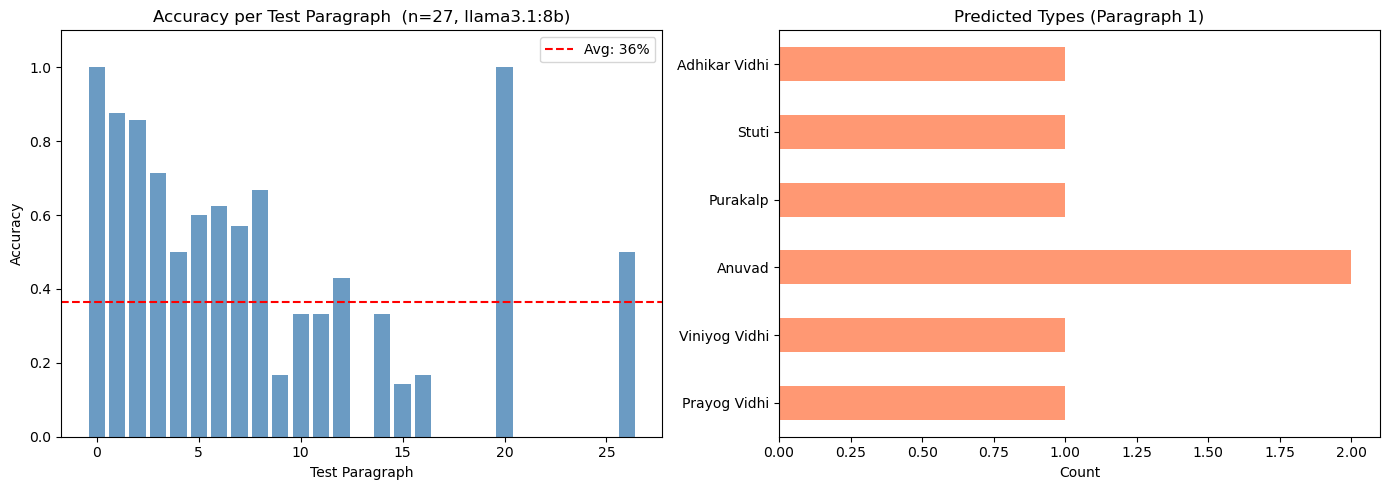

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accs = [a["Accuracy"] for a in accuracies]
axes[0].bar(range(len(accs)), accs, color="steelblue", alpha=0.8)
axes[0].axhline(y=avg, color="red", linestyle="--", label=f"Avg: {avg:.0%}")
axes[0].set_xlabel("Test Paragraph"); axes[0].set_ylabel("Accuracy")
axes[0].set_title(f"Accuracy per Test Paragraph  (n={len(test_data)}, {MODEL})")
axes[0].set_ylim(0, 1.1); axes[0].legend()

tc = {}
for r in results_p1:
    tc[r["type"]] = tc.get(r["type"], 0) + 1
pd.Series(tc).plot(kind="barh", ax=axes[1], color="coral", alpha=0.8)
axes[1].set_xlabel("Count"); axes[1].set_title("Predicted Types (Paragraph 1)")
plt.tight_layout()
import pathlib
out_path = pathlib.Path.cwd() / "rag_results.png"  # saves in notebook folder
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()